# Mecánica cuántica 
## Estados ligados

Objetivo: Determinar numéricamente las energías permitidas de una partícula confinada en un pozo cuadrado unidimensional utilizando un algoritmo de búsqueda de raíces.

Este problema puede ser abordado con algunos de los siguientes métodos numéricos:

- Estados ligados 
- Ecuaciones trascendentales
- Métodos numéricos de búsqueda de raíces (por ejemplo, método de bisección, método de Newton-Raphson)

## Pozo cuadrado finito

El potencial del pozo finito simétrico viene dado por:

$$V(x) = \begin{cases} 
-V_0, & \text{si } |x| \leq R \\
0, & \text{si } |x| > R
\end{cases}$$

Para estados ligados es útil trabajar con la energía de ligadura $E_B > 0$, definida por

$$E = -E_B, \qquad 0 < E_B < V_0$$

De este modo, en la notación adimensional que usa el profesor, las ecuaciones trascendentales se escriben como:

- Estados pares:

$$\sqrt{V_0 - E_B}\tan\left(\sqrt{V_0 - E_B}\right) = \sqrt{E_B}$$

- Estados impares:

$$-\sqrt{V_0 - E_B}\cot\left(\sqrt{V_0 - E_B}\right) = \sqrt{E_B}$$

Llevando todo al lado izquierdo, las funciones cuyas raíces buscamos son:

$$f_{\mathrm{par}}(E_B) = \sqrt{V_0 - E_B}\tan\left(\sqrt{V_0 - E_B}\right) - \sqrt{E_B}$$

$$f_{\mathrm{impar}}(E_B) = -\sqrt{V_0 - E_B}\cot\left(\sqrt{V_0 - E_B}\right) - \sqrt{E_B}$$

## Método de bisección

El problema consiste en encontrar los valores de $E_B$ para los cuales

$$f_{\mathrm{par}}(E_B) = 0 \qquad \text{o} \qquad f_{\mathrm{impar}}(E_B) = 0$$

El método de bisección se aplica sobre un intervalo $[a,b] \subset (0,V_0)$ tal que la función cambie de signo:

$$f(a)f(b) < 0$$

donde $f$ puede ser $f_{\mathrm{par}}$ o $f_{\mathrm{impar}}$. El algoritmo es:

1. Elegir un intervalo inicial $[a,b]$ donde exista cambio de signo.
2. Calcular el punto medio $c = \dfrac{a+b}{2}$.
3. Evaluar $f(c)$.
4. Si $f(a)f(c) < 0$, la raíz está en $[a,c]$; en caso contrario, está en $[c,b]$.
5. Repetir el proceso hasta que $|f(c)| < \varepsilon$ o hasta que el intervalo sea suficientemente pequeño.

En este problema hay que escoger los intervalos con cuidado, porque las funciones $\tan$ y $\cot$ tienen singularidades. Por ello, conviene buscar raíces por separado en cada rama continua de $f_{\mathrm{par}}$ y de $f_{\mathrm{impar}}$.

Al encontrar una raíz $E_B$, la energía del estado ligado correspondiente es

$$E = -E_B$$

## Shooting Method

Otra forma de encontrar los estados ligados del pozo finito es el **Shooting Method**. En este enfoque no se parte de la ecuación trascendental, sino de la ecuación de Schrödinger estacionaria y se transforma el problema en uno de valor inicial.

La idea física es la siguiente: se propone un valor de energía $E$, se integra numéricamente la función de onda $\psi(x)$ y se verifica si la solución obtenida satisface las condiciones de frontera de un estado ligado. Si no las satisface, se corrige el valor de $E$ y se repite el proceso hasta converger.

De acuerdo con el enfoque usado por el profesor y siguiendo como referencia a **Landau**, este método involucra dos ingredientes principales:

1. **RK4:** se usa el método de Runge-Kutta de cuarto orden para integrar numéricamente la ecuación diferencial.
2. **Búsqueda iterativa:** se ajusta la energía de prueba hasta que la solución cumpla la condición física correcta en la frontera.

En términos esquemáticos, el procedimiento es:

1. Escribir la ecuación de Schrödinger como un sistema de dos ecuaciones de primer orden.
2. Elegir condiciones iniciales compatibles con la paridad del estado buscado.
3. Proponer una energía de prueba $E$.
4. Integrar la solución con **RK4** desde un punto inicial hasta la frontera del dominio.
5. Medir el error de frontera, por ejemplo el valor de $\psi$ o de su derivada en el extremo.
6. Modificar $E$ mediante una búsqueda iterativa hasta hacer ese error lo más pequeño posible.

La diferencia con el enfoque anterior es importante:

- Con las **ecuaciones trascendentales**, primero se reduce el problema a buscar raíces de $f_{\mathrm{par}}(E_B)$ y $f_{\mathrm{impar}}(E_B)$.
- Con el **Shooting Method**, se integra directamente la ecuación de Schrödinger y la energía se ajusta iterativamente hasta obtener una función de onda físicamente aceptable.

Físicamente, el método de disparo es más general, porque puede aplicarse incluso cuando no se dispone de una ecuación trascendental simple. Por eso en problemas más complejos suele ser el enfoque más útil. En este curso, cuando se use este método, la referencia algorítmica debe mantenerse alineada con **Landau**.

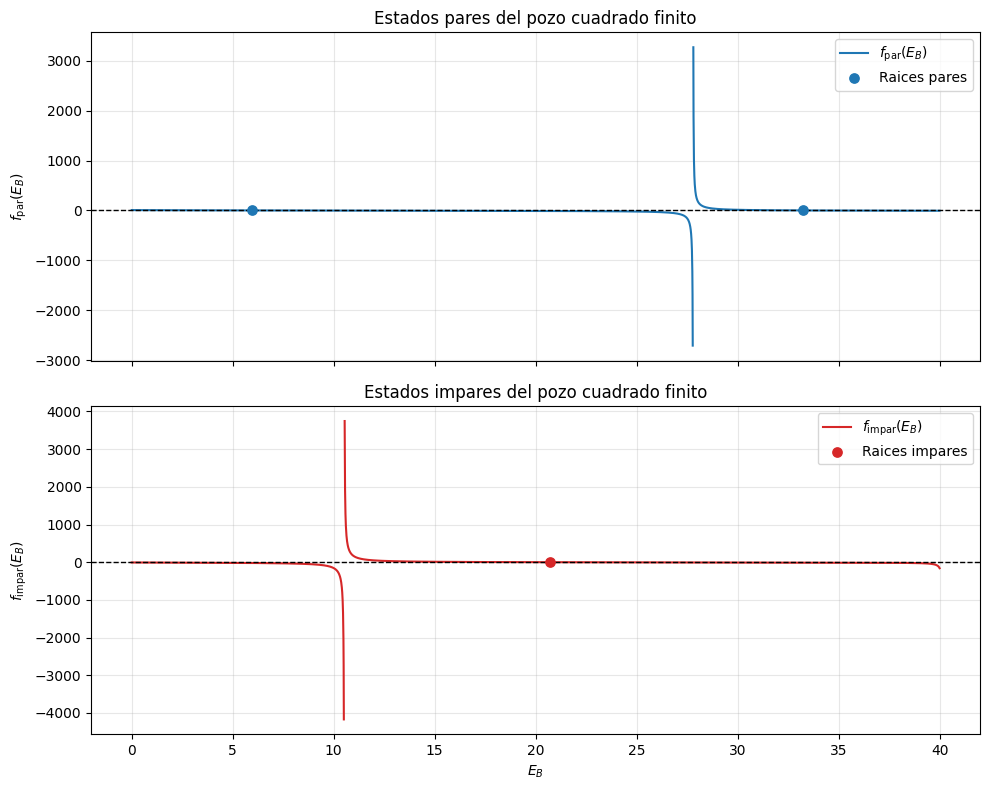

Raices pares encontradas:
  E_B = 5.96536515  ->  E = -5.96536515
  E_B = 33.23279249  ->  E = -33.23279249
Raices impares encontradas:
  E_B = 20.71411100  ->  E = -20.71411100


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Implementacion del metodo de biseccion para buscar raices de funciones escalares.
def Bisection(fun, Xminus, Xplus, Nmax=100, eps=1e-8):
    f_minus = fun(Xminus)
    f_plus = fun(Xplus)

    if abs(f_minus) < eps:
        return Xminus
    if abs(f_plus) < eps:
        return Xplus

    if f_minus * f_plus > 0:
        raise ValueError('El intervalo inicial no encierra una raiz: f(Xminus) y f(Xplus) tienen el mismo signo.')

    for _ in range(Nmax):
        Xmiddle = 0.5 * (Xminus + Xplus)
        f_middle = fun(Xmiddle)

        if abs(f_middle) < eps or 0.5 * abs(Xplus - Xminus) < eps:
            return Xmiddle

        if f_minus * f_middle < 0:
            Xplus = Xmiddle
            f_plus = f_middle
        else:
            Xminus = Xmiddle
            f_minus = f_middle

    return 0.5 * (Xminus + Xplus)

# Profundidad del pozo en la notacion usada por el profesor
V_0 = 50

# Energia de ligadura a explorar para la grafica
E_B = np.linspace(1e-6, 40, 4000)

# Definimos las funciones escalares cuyas raices determinan los estados ligados.
def f_par_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return argumento * np.tan(argumento) - np.sqrt(E_B)

def f_impar_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return -argumento / np.tan(argumento) - np.sqrt(E_B)

# Recorremos el intervalo 0 < E_B < 40 para detectar cambios de signo sin cruzar singularidades.
def encontrar_raices(fun, mascara_singularidad, numero_puntos=6000):
    E_malla = np.linspace(1e-6, 40, numero_puntos)
    argumento_malla = np.sqrt(V_0 - E_malla)

    with np.errstate(divide='ignore', invalid='ignore'):
        valores = fun(E_malla)

    mascara_valida = np.isfinite(valores) & (~mascara_singularidad(argumento_malla))
    raices = []

    for i in range(len(E_malla) - 1):
        if not (mascara_valida[i] and mascara_valida[i + 1]):
            continue

        x_izq = E_malla[i]
        x_der = E_malla[i + 1]
        f_izq = valores[i]
        f_der = valores[i + 1]

        if abs(f_izq) < 1e-6:
            raices.append(x_izq)
            continue

        if f_izq * f_der < 0:
            raiz = Bisection(fun, x_izq, x_der, Nmax=100, eps=1e-10)

            if len(raices) == 0 or abs(raiz - raices[-1]) > 1e-4:
                raices.append(raiz)

    return np.array(raices)

def singularidad_par(argumento):
    return np.abs(np.cos(argumento)) < 1e-3

def singularidad_impar(argumento):
    return np.abs(np.sin(argumento)) < 1e-3

raices_pares = encontrar_raices(f_par_escalar, singularidad_par)
raices_impares = encontrar_raices(f_impar_escalar, singularidad_impar)

# Variable auxiliar que aparece dentro de las funciones trascendentales
argumento = np.sqrt(V_0 - E_B)

# Evaluamos las funciones en forma vectorizada.
# Usamos errstate para evitar advertencias espurias cerca de las singularidades.
with np.errstate(divide='ignore', invalid='ignore'):
    f_par = f_par_escalar(E_B)
    f_impar = f_impar_escalar(E_B)

# En los puntos donde cos(argumento)=0 o sin(argumento)=0 aparecen singularidades.
# Reemplazamos esos valores por NaN para que la grafica no una ramas que no corresponden.
tolerancia = 1e-3
f_par[np.abs(np.cos(argumento)) < tolerancia] = np.nan
f_impar[np.abs(np.sin(argumento)) < tolerancia] = np.nan

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(E_B, f_par, color='tab:blue', label=r'$f_{\mathrm{par}}(E_B)$')
axes[0].scatter(raices_pares, np.zeros_like(raices_pares), color='tab:blue', s=45, zorder=3, label='Raices pares')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel(r'$f_{\mathrm{par}}(E_B)$')
axes[0].set_title('Estados pares del pozo cuadrado finito')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(E_B, f_impar, color='tab:red', label=r'$f_{\mathrm{impar}}(E_B)$')
axes[1].scatter(raices_impares, np.zeros_like(raices_impares), color='tab:red', s=45, zorder=3, label='Raices impares')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel(r'$E_B$')
axes[1].set_ylabel(r'$f_{\mathrm{impar}}(E_B)$')
axes[1].set_title('Estados impares del pozo cuadrado finito')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Raices pares encontradas:')
for raiz in raices_pares:
    print(f'  E_B = {raiz:.8f}  ->  E = {-raiz:.8f}')

print('Raices impares encontradas:')
for raiz in raices_impares:
    print(f'  E_B = {raiz:.8f}  ->  E = {-raiz:.8f}')

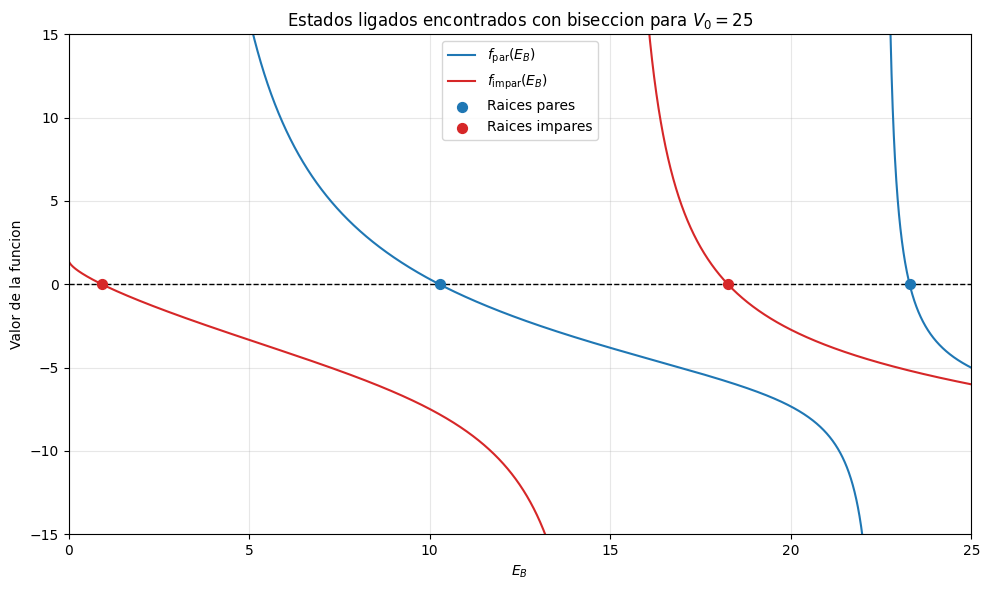

Raices pares encontradas:
  E_B = 10.27384621  ->  E = -10.27384621
  E_B = 23.29321450  ->  E = -23.29321450
Raices impares encontradas:
  E_B = 0.92826789  ->  E = -0.92826789
  E_B = 18.26213863  ->  E = -18.26213863


In [16]:
# Ejemplo concreto: pozo finito con profundidad V_0 = 25
import numpy as np
import matplotlib.pyplot as plt

# En este ejemplo trabajamos con la misma notacion del profesor.
# La variable E_B representa la energia de ligadura y debe cumplir 0 < E_B < V_0.
V_0 = 25
E_B = np.linspace(1e-6, V_0 - 1e-6, 4000)

# Definimos las funciones escalares cuyas raices determinan los estados ligados.
def f_par_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return argumento * np.tan(argumento) - np.sqrt(E_B)

def f_impar_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return -argumento / np.tan(argumento) - np.sqrt(E_B)

# Recorremos el intervalo 0 < E_B < V_0 para detectar cambios de signo sin cruzar singularidades.
def encontrar_raices(fun, mascara_singularidad, numero_puntos=6000):
    E_malla = np.linspace(1e-6, V_0 - 1e-6, numero_puntos)
    argumento_malla = np.sqrt(V_0 - E_malla)

    with np.errstate(divide='ignore', invalid='ignore'):
        valores = fun(E_malla)

    mascara_valida = np.isfinite(valores) & (~mascara_singularidad(argumento_malla))
    raices = []

    for i in range(len(E_malla) - 1):
        if not (mascara_valida[i] and mascara_valida[i + 1]):
            continue

        x_izq = E_malla[i]
        x_der = E_malla[i + 1]
        f_izq = valores[i]
        f_der = valores[i + 1]

        if abs(f_izq) < 1e-6:
            raices.append(x_izq)
            continue

        if f_izq * f_der < 0:
            raiz = Bisection(fun, x_izq, x_der, Nmax=100, eps=1e-10)

            if len(raices) == 0 or abs(raiz - raices[-1]) > 1e-4:
                raices.append(raiz)

    return np.array(raices)

def singularidad_par(argumento):
    return np.abs(np.cos(argumento)) < 1e-3

def singularidad_impar(argumento):
    return np.abs(np.sin(argumento)) < 1e-3

raices_pares = encontrar_raices(f_par_escalar, singularidad_par)
raices_impares = encontrar_raices(f_impar_escalar, singularidad_impar)

# Construimos una grafica conjunta y marcamos las raices encontradas.
argumento = np.sqrt(V_0 - E_B)

with np.errstate(divide='ignore', invalid='ignore'):
    f_par = f_par_escalar(E_B)
    f_impar = f_impar_escalar(E_B)

f_par[singularidad_par(argumento)] = np.nan
f_impar[singularidad_impar(argumento)] = np.nan

plt.figure(figsize=(10, 6))
plt.plot(E_B, f_par, color='tab:blue', label=r'$f_{\mathrm{par}}(E_B)$')
plt.plot(E_B, f_impar, color='tab:red', label=r'$f_{\mathrm{impar}}(E_B)$')
plt.scatter(raices_pares, np.zeros_like(raices_pares), color='tab:blue', s=50, zorder=3, label='Raices pares')
plt.scatter(raices_impares, np.zeros_like(raices_impares), color='tab:red', s=50, zorder=3, label='Raices impares')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim(0, V_0)
plt.ylim(-15, 15)
plt.xlabel(r'$E_B$')
plt.ylabel('Valor de la funcion')
plt.title('Estados ligados encontrados con biseccion para $V_0 = 25$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Raices pares encontradas:')
for raiz in raices_pares:
    print(f'  E_B = {raiz:.8f}  ->  E = {-raiz:.8f}')

print('Raices impares encontradas:')
for raiz in raices_impares:
    print(f'  E_B = {raiz:.8f}  ->  E = {-raiz:.8f}')

In [17]:
# Implementacion del metodo de biseccion para buscar raices de funciones escalares.
def Bisection(fun, Xminus, Xplus, Nmax=100, eps=1e-8):
    # Evaluamos la funcion en los extremos del intervalo inicial.
    f_minus = fun(Xminus)
    f_plus = fun(Xplus)

    # Si alguno de los extremos ya es raiz, lo devolvemos de inmediato.
    if abs(f_minus) < eps:
        return Xminus
    if abs(f_plus) < eps:
        return Xplus

    # El metodo de biseccion requiere que exista un cambio de signo en el intervalo.
    if f_minus * f_plus > 0:
        raise ValueError('El intervalo inicial no encierra una raiz: f(Xminus) y f(Xplus) tienen el mismo signo.')

    # Repetimos el refinamiento del intervalo hasta alcanzar la tolerancia deseada
    # o hasta llegar al numero maximo de iteraciones.
    for _ in range(Nmax):
        Xmiddle = 0.5 * (Xminus + Xplus)
        f_middle = fun(Xmiddle)

        # Si el valor de la funcion o el tamano del intervalo son suficientemente pequenos,
        # aceptamos el punto medio como aproximacion de la raiz.
        if abs(f_middle) < eps or 0.5 * abs(Xplus - Xminus) < eps:
            return Xmiddle

        # Conservamos la mitad del intervalo donde sigue habiendo cambio de signo.
        if f_minus * f_middle < 0:
            Xplus = Xmiddle
            f_plus = f_middle
        else:
            Xminus = Xmiddle
            f_minus = f_middle

    # Si se agotan las iteraciones, devolvemos la mejor aproximacion disponible.
    return 0.5 * (Xminus + Xplus)

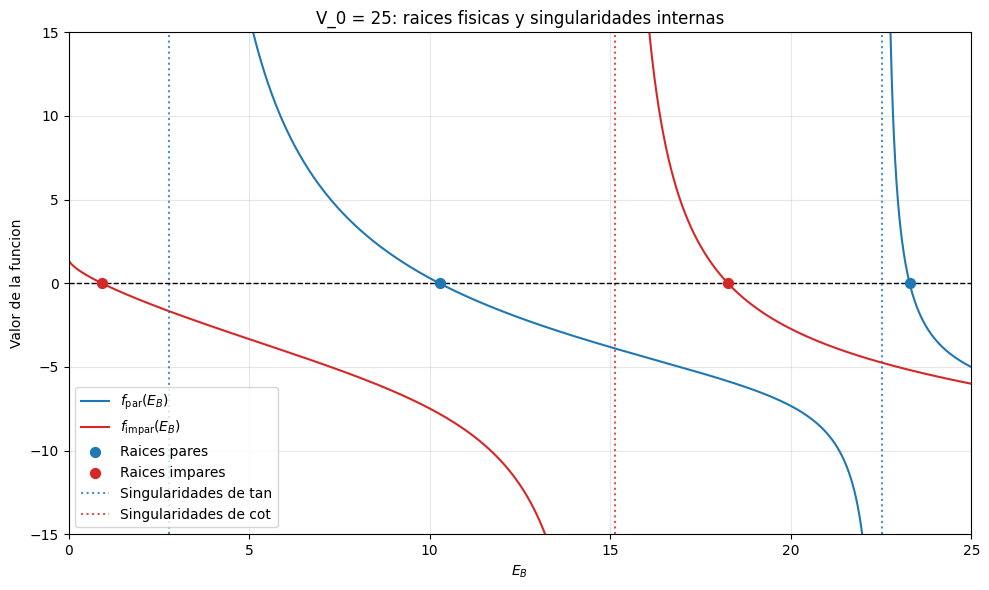

Raices pares encontradas:
  E_B = 10.27384621
  E_B = 23.29321450
Raices impares encontradas:
  E_B = 0.92826789
  E_B = 18.26213863
Singularidades internas de tan:
  E_B = 22.53259890
  E_B = 2.79339010
Singularidades internas de cot:
  E_B = 15.13039560
Total para comparar = 7


In [18]:
# Comparacion para V_0 = 25 incluyendo raices fisicas y singularidades internas
import numpy as np
import matplotlib.pyplot as plt

V_0 = 25
E_B = np.linspace(1e-6, V_0 - 1e-6, 4000)

def f_par_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return argumento * np.tan(argumento) - np.sqrt(E_B)

def f_impar_escalar(E_B):
    argumento = np.sqrt(V_0 - E_B)
    return -argumento / np.tan(argumento) - np.sqrt(E_B)

def encontrar_raices(fun, mascara_singularidad, numero_puntos=6000):
    E_malla = np.linspace(1e-6, V_0 - 1e-6, numero_puntos)
    argumento_malla = np.sqrt(V_0 - E_malla)

    with np.errstate(divide='ignore', invalid='ignore'):
        valores = fun(E_malla)

    mascara_valida = np.isfinite(valores) & (~mascara_singularidad(argumento_malla))
    raices = []

    for i in range(len(E_malla) - 1):
        if not (mascara_valida[i] and mascara_valida[i + 1]):
            continue

        x_izq = E_malla[i]
        x_der = E_malla[i + 1]
        f_izq = valores[i]
        f_der = valores[i + 1]

        if abs(f_izq) < 1e-6:
            raices.append(x_izq)
            continue

        if f_izq * f_der < 0:
            raiz = Bisection(fun, x_izq, x_der, Nmax=100, eps=1e-10)

            if len(raices) == 0 or abs(raiz - raices[-1]) > 1e-4:
                raices.append(raiz)

    return np.array(raices)

def singularidad_par(argumento):
    return np.abs(np.cos(argumento)) < 1e-3

def singularidad_impar(argumento):
    return np.abs(np.sin(argumento)) < 1e-3

# Raices fisicas de las ecuaciones trascendentales
raices_pares = encontrar_raices(f_par_escalar, singularidad_par)
raices_impares = encontrar_raices(f_impar_escalar, singularidad_impar)

# Singularidades internas en 0 < E_B < V_0
z_tan = []
n = 0
while (2 * n + 1) * np.pi / 2 < np.sqrt(V_0):
    z_tan.append((2 * n + 1) * np.pi / 2)
    n += 1

z_cot = []
n = 1
while n * np.pi < np.sqrt(V_0):
    z_cot.append(n * np.pi)
    n += 1

singularidades_tan = V_0 - np.array(z_tan) ** 2
singularidades_cot = V_0 - np.array(z_cot) ** 2
singularidades_totales = np.sort(np.concatenate([singularidades_tan, singularidades_cot]))

argumento = np.sqrt(V_0 - E_B)
with np.errstate(divide='ignore', invalid='ignore'):
    f_par = f_par_escalar(E_B)
    f_impar = f_impar_escalar(E_B)

f_par[singularidad_par(argumento)] = np.nan
f_impar[singularidad_impar(argumento)] = np.nan

plt.figure(figsize=(10, 6))
plt.plot(E_B, f_par, color='tab:blue', label=r'$f_{\mathrm{par}}(E_B)$')
plt.plot(E_B, f_impar, color='tab:red', label=r'$f_{\mathrm{impar}}(E_B)$')
plt.scatter(raices_pares, np.zeros_like(raices_pares), color='tab:blue', s=50, zorder=3, label='Raices pares')
plt.scatter(raices_impares, np.zeros_like(raices_impares), color='tab:red', s=50, zorder=3, label='Raices impares')

for i, singularidad in enumerate(singularidades_tan):
    etiqueta = 'Singularidades de tan' if i == 0 else None
    plt.axvline(singularidad, color='tab:blue', linestyle=':', alpha=0.8, label=etiqueta)

for i, singularidad in enumerate(singularidades_cot):
    etiqueta = 'Singularidades de cot' if i == 0 else None
    plt.axvline(singularidad, color='tab:red', linestyle=':', alpha=0.8, label=etiqueta)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim(0, V_0)
plt.ylim(-15, 15)
plt.xlabel(r'$E_B$')
plt.ylabel('Valor de la funcion')
plt.title('V_0 = 25: raices fisicas y singularidades internas')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Raices pares encontradas:')
for raiz in raices_pares:
    print(f'  E_B = {raiz:.8f}')

print('Raices impares encontradas:')
for raiz in raices_impares:
    print(f'  E_B = {raiz:.8f}')

print('Singularidades internas de tan:')
for singularidad in singularidades_tan:
    print(f'  E_B = {singularidad:.8f}')

print('Singularidades internas de cot:')
for singularidad in singularidades_cot:
    print(f'  E_B = {singularidad:.8f}')

print(f'Total para comparar = {len(raices_pares) + len(raices_impares) + len(singularidades_totales)}')